In [1]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("mps available:", torch.backends.mps.is_available())

torch: 2.13.0
torchvision: 0.28.0
mps available: True


In [2]:
import pandas as pd
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

df = pd.read_csv("../outputs/final_split.csv")

print("device:", device)
print(df["split"].value_counts())
print("classes:", df["label"].nunique())
print("total:", len(df))

device: mps
split
train         3125
validation     684
test           684
Name: count, dtype: int64
classes: 18
total: 4493


In [3]:
# buat preprocessing yang mempertahankan aspect ratio

from PIL import ImageOps
from torchvision import transforms

IMAGE_SIZE = 224

class PadToSquare:
    def __call__(self, image):
        width, height = image.size
        max_side = max(width, height)

        pad_left = (max_side - width) // 2
        pad_right = max_side - width - pad_left
        pad_top = (max_side - height) // 2
        pad_bottom = max_side - height - pad_top

        return ImageOps.expand(
            image,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill="white"
        )

base_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

print(base_transform)

Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


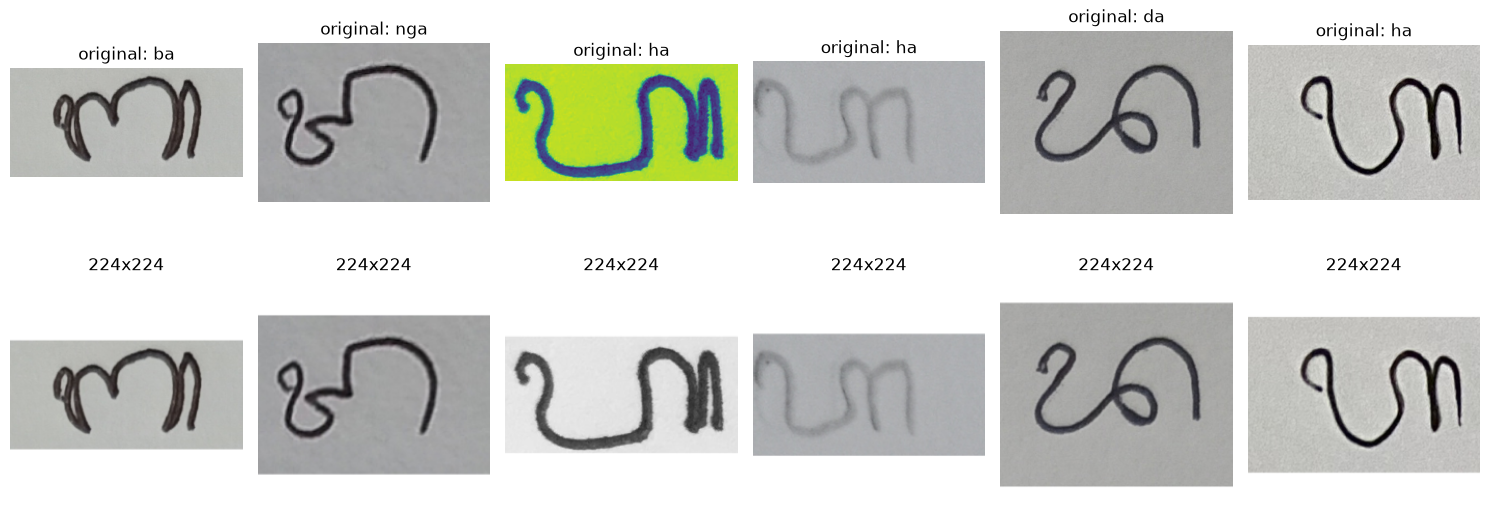

In [4]:
# visual check preprocessing
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_rows = df.sample(6, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(15, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["path"])

    # original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'original: {row["label"]}')
    axes[0, i].axis("off")

    # transformed
    transformed = base_transform(img)
    transformed_img = transformed.permute(1, 2, 0)

    axes[1, i].imshow(transformed_img)
    axes[1, i].set_title("224x224")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
from collections import Counter
from PIL import Image

modes = Counter()

for _, row in df.iterrows():
    with Image.open(row["path"]) as img:
        modes[img.mode] += 1

print(modes)

Counter({'RGB': 4026, 'L': 467})


In [6]:
class_names = sorted(df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print(class_to_idx)
print("total classes:", len(class_to_idx))

{'ba': 0, 'ca': 1, 'da': 2, 'ga': 3, 'ha': 4, 'ja': 5, 'ka': 6, 'la': 7, 'ma': 8, 'na': 9, 'nga': 10, 'nya': 11, 'pa': 12, 'ra': 13, 'sa': 14, 'ta': 15, 'wa': 16, 'ya': 17}
total classes: 18


buat custom dataset

sekarang kita bikin Dataset PyTorch yang membaca:

path image
label
transform preprocessing

buat cell baru:

In [7]:
from torch.utils.data import Dataset
from PIL import Image

class BalineseHandwritingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["path"])
        label = class_to_idx[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label


train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

train_dataset = BalineseHandwritingDataset(
    train_df,
    transform=base_transform
)

val_dataset = BalineseHandwritingDataset(
    val_df,
    transform=base_transform
)

test_dataset = BalineseHandwritingDataset(
    test_df,
    transform=base_transform
)

print("train:", len(train_dataset))
print("validation:", len(val_dataset))
print("test:", len(test_dataset))

train: 3125
validation: 684
test: 684


In [ ]:
# bikin dataloader + cek satu batch
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("min pixel:", images.min().item())
print("max pixel:", images.max().item())

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
min pixel: 0.0
max pixel: 1.0


In [9]:
# buat baseline cnn

import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=18):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = BaselineCNN(num_classes=18).to(device)

total_params = sum(p.numel() for p in model.parameters())

print(model)
print("\ntotal parameters:", total_params)
print("device:", next(model.parameters()).device)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=18, bias=True)
)

total para

In [10]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("output shape:", outputs.shape)
print("label shape:", labels.shape)
print("loss:", loss.item())

output shape: torch.Size([32, 18])
label shape: torch.Size([32])
loss: 2.8683547973632812


In [11]:
# define training loop

import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total
    acc = correct / total

    return loss, acc

## 6. Baseline CNN Training

A simple CNN is trained from scratch as the baseline model for the 18-class Balinese handwriting classification task.

The purpose of this baseline is to establish an initial performance benchmark before experimenting with more advanced architectures such as MobileNetV3 or EfficientNet-B0.

Training is monitored using:
- training loss
- training accuracy
- validation loss
- validation accuracy

The model with the highest validation accuracy is saved for later evaluation.

In [13]:
# train baseline

import torch
import torch.optim as optim

# reset model supaya training baseline reproducible
torch.manual_seed(42)

model = BaselineCNN(num_classes=18).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15

history = []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "../outputs/baseline_cnn_best.pt"
        )

    print(
        f"epoch {epoch+1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.4f}"
    )

print(f"\nbest validation accuracy: {best_val_acc:.4f}")

epoch 01/15 | train loss: 2.8386 | train acc: 0.0960 | val loss: 2.7882 | val acc: 0.1067
epoch 02/15 | train loss: 2.7677 | train acc: 0.1274 | val loss: 2.7464 | val acc: 0.1594
epoch 03/15 | train loss: 2.7371 | train acc: 0.1235 | val loss: 2.7702 | val acc: 0.1199
epoch 04/15 | train loss: 2.7060 | train acc: 0.1402 | val loss: 2.7560 | val acc: 0.1126
epoch 05/15 | train loss: 2.6739 | train acc: 0.1514 | val loss: 2.6528 | val acc: 0.1725
epoch 06/15 | train loss: 2.6349 | train acc: 0.1722 | val loss: 2.6130 | val acc: 0.1827
epoch 07/15 | train loss: 2.6042 | train acc: 0.1862 | val loss: 3.6893 | val acc: 0.0629
epoch 08/15 | train loss: 2.5723 | train acc: 0.1917 | val loss: 2.6353 | val acc: 0.1491
epoch 09/15 | train loss: 2.5423 | train acc: 0.2099 | val loss: 2.7302 | val acc: 0.1199
epoch 10/15 | train loss: 2.5112 | train acc: 0.2186 | val loss: 2.7152 | val acc: 0.1637
epoch 11/15 | train loss: 2.4742 | train acc: 0.2298 | val loss: 2.4487 | val acc: 0.2310
epoch 12/1

## 7. Baseline CNN Training Analysis

The baseline CNN showed that the model was able to learn patterns from the dataset, but its performance remained limited.

The best validation accuracy was 23.1%, while training accuracy reached 28.2% after 15 epochs. Since both training and validation performance remained relatively low, the model appears to be underfitting rather than overfitting.

The baseline will be used as a reference point before experimenting with a stronger pretrained architecture.

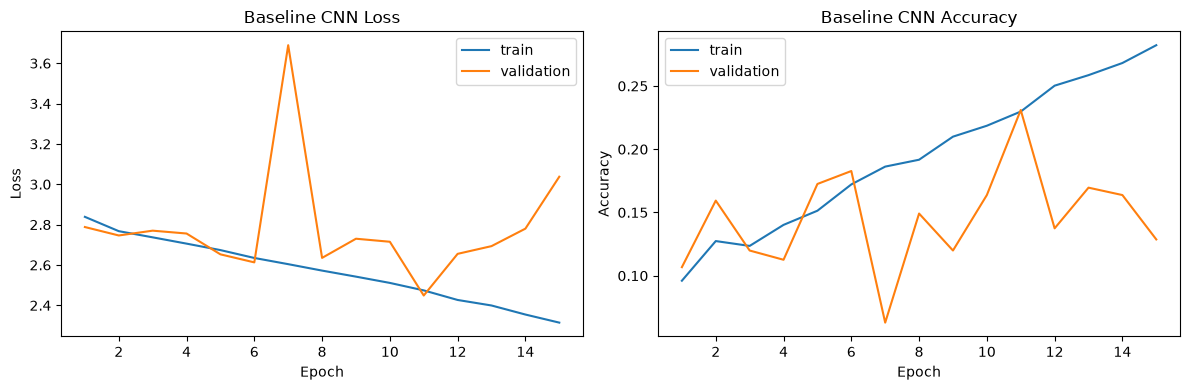

In [14]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="train"
)

axes[0].plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="validation"
)

axes[0].set_title("Baseline CNN Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Accuracy
axes[1].plot(
    history_df["epoch"],
    history_df["train_acc"],
    label="train"
)

axes[1].plot(
    history_df["epoch"],
    history_df["val_acc"],
    label="validation"
)

axes[1].set_title("Baseline CNN Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

grafiknya mengonfirmasi analisis tadi:

* train loss turun konsisten → model memang belajar
* train accuracy terus naik
* validation sangat fluktuatif
* best val accuracy cuma **23.1%**
* jadi baseline ini **underfitting + generalization-nya lemah**

ini sudah cukup sebagai baseline. kita **jangan utak-atik custom cnn ini dulu**. sekarang masuk ke **initial iteration: transfer learning dengan MobileNetV3**.



## 8. Initial Iteration — MobileNetV3 Transfer Learning

The baseline CNN achieved a best validation accuracy of 23.1%, indicating that the simple model was not expressive enough for the handwriting classification task.

As the first model iteration, MobileNetV3-Large with ImageNet pretrained weights is used through transfer learning.

MobileNetV3 is selected because it:
- provides a stronger pretrained visual representation
- is designed with mobile deployment efficiency in mind
- can later be converted to Core ML for on-device inference

For the first stage, the pretrained feature extractor is frozen and only the final classifier is trained for the 18 Balinese character classes.

The test set remains untouched during model development.

In [15]:
from torchvision import transforms

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

mobilenet_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print(mobilenet_transform)

Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 8. Initial Iteration — MobileNetV3 Transfer Learning

The baseline CNN achieved a best validation accuracy of 23.1%, which indicates limited performance and underfitting.

As the first model iteration, MobileNetV3-Large with pretrained ImageNet weights is used through transfer learning.

MobileNetV3 is selected because it provides stronger visual feature representations while remaining relatively efficient for mobile deployment.

For this experiment:
- pretrained ImageNet weights are used
- the feature extractor is initially frozen
- only the final classifier is trained for the 18 Balinese character classes
- the test set remains untouched during model development

In [16]:
from torchvision import transforms

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

mobilenet_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print(mobilenet_transform)

Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### MobileNetV3 Dataset and DataLoaders

The same train, validation, and test split is reused to ensure a fair comparison with the baseline CNN.

The difference is only in the preprocessing pipeline, which now uses ImageNet normalization required by the pretrained MobileNetV3 model.

In [17]:
mobilenet_train_dataset = BalineseHandwritingDataset(
    train_df,
    transform=mobilenet_transform
)

mobilenet_val_dataset = BalineseHandwritingDataset(
    val_df,
    transform=mobilenet_transform
)

mobilenet_test_dataset = BalineseHandwritingDataset(
    test_df,
    transform=mobilenet_transform
)

mobilenet_train_loader = DataLoader(
    mobilenet_train_dataset,
    batch_size=32,
    shuffle=True
)

mobilenet_val_loader = DataLoader(
    mobilenet_val_dataset,
    batch_size=32,
    shuffle=False
)

mobilenet_test_loader = DataLoader(
    mobilenet_test_dataset,
    batch_size=32,
    shuffle=False
)

images, labels = next(iter(mobilenet_train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("train samples:", len(mobilenet_train_dataset))
print("validation samples:", len(mobilenet_val_dataset))
print("test samples:", len(mobilenet_test_dataset))

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
train samples: 3125
validation samples: 684
test samples: 684


### MobileNetV3-Large Model Setup

A MobileNetV3-Large model pretrained on ImageNet is used as the first transfer learning experiment.

The pretrained feature extractor is frozen so that the model retains its previously learned visual representations, while only the classifier is trained for the 18 Balinese handwriting classes.

This allows the experiment to test whether pretrained visual features provide a stronger starting point than the baseline CNN trained from scratch.

In [18]:
from torchvision import models
import torch.nn as nn

# Load pretrained MobileNetV3-Large
weights = models.MobileNet_V3_Large_Weights.DEFAULT

mobilenet_model = models.mobilenet_v3_large(
    weights=weights
)

# Freeze pretrained feature extractor
for param in mobilenet_model.features.parameters():
    param.requires_grad = False

# Replace ImageNet classifier (1000 classes) with 18 Balinese classes
in_features = mobilenet_model.classifier[3].in_features

mobilenet_model.classifier[3] = nn.Linear(
    in_features,
    18
)

mobilenet_model = mobilenet_model.to(device)

# Count parameters
total_params = sum(
    p.numel()
    for p in mobilenet_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in mobilenet_model.parameters()
    if p.requires_grad
)

print(mobilenet_model.classifier)

print("\ntotal parameters:", total_params)
print("trainable parameters:", trainable_params)
print("device:", next(mobilenet_model.parameters()).device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /Users/kevinwilliamfaith/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100.0%


Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=18, bias=True)
)

total parameters: 4225090
trainable parameters: 1253138
device: mps:0


### MobileNetV3 Forward-Pass Sanity Check

Before training, a single batch is passed through the MobileNetV3 model to verify that:

- the input tensor shape is compatible with the model
- the classifier produces logits for 18 classes
- the loss can be computed correctly
- the model runs successfully on Apple Silicon through MPS

In [19]:
criterion = nn.CrossEntropyLoss()

images, labels = next(iter(mobilenet_train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = mobilenet_model(images)
loss = criterion(outputs, labels)

print("input shape:", images.shape)
print("output shape:", outputs.shape)
print("label shape:", labels.shape)
print("initial loss:", loss.item())

input shape: torch.Size([32, 3, 224, 224])
output shape: torch.Size([32, 18])
label shape: torch.Size([32])
initial loss: 2.8912532329559326


### Stage 1 Training Configuration

In the first transfer learning stage, the pretrained MobileNetV3 feature extractor remains frozen.

Only the classifier parameters are optimized for the 18 Balinese handwriting classes.

AdamW is used with a relatively small learning rate to adapt the pretrained model without making overly aggressive updates.

In [20]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, mobilenet_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_STAGE1 = 10

print(
    "trainable parameters:",
    sum(
        p.numel()
        for p in mobilenet_model.parameters()
        if p.requires_grad
    )
)

print("learning rate:", optimizer.param_groups[0]["lr"])
print("epochs:", EPOCHS_STAGE1)

trainable parameters: 1253138
learning rate: 0.001
epochs: 10


### Stage 1 — Frozen Backbone Training

The pretrained MobileNetV3 feature extractor is kept frozen while the classifier is trained on the Balinese handwriting dataset.

During training, the feature extractor remains in evaluation mode to preserve the pretrained BatchNorm statistics.

The model with the highest validation accuracy is saved as the best Stage 1 checkpoint. The test set is not used during this stage.

In [21]:
def train_one_epoch_frozen_backbone(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Keep pretrained feature extractor frozen,
    # including BatchNorm running statistics
    model.features.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### MobileNetV3 Stage 1 Training

The MobileNetV3 classifier is trained for 10 epochs while keeping the pretrained feature extractor frozen.

Training and validation performance are monitored at each epoch, and the checkpoint with the highest validation accuracy is saved for later comparison and possible fine-tuning.

In [22]:
mobilenet_history_stage1 = []
best_val_acc_stage1 = 0.0

for epoch in range(EPOCHS_STAGE1):

    train_loss, train_acc = train_one_epoch_frozen_backbone(
        mobilenet_model,
        mobilenet_train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        mobilenet_model,
        mobilenet_val_loader,
        criterion,
        device
    )

    mobilenet_history_stage1.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    if val_acc > best_val_acc_stage1:
        best_val_acc_stage1 = val_acc

        torch.save(
            mobilenet_model.state_dict(),
            "../outputs/mobilenetv3_stage1_best.pt"
        )

    print(
        f"epoch {epoch + 1:02d}/{EPOCHS_STAGE1} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.4f}"
    )

print(
    f"\nbest validation accuracy: "
    f"{best_val_acc_stage1:.4f}"
)

epoch 01/10 | train loss: 1.9157 | train acc: 0.4086 | val loss: 1.2141 | val acc: 0.6316
epoch 02/10 | train loss: 0.9057 | train acc: 0.7171 | val loss: 0.8551 | val acc: 0.7266
epoch 03/10 | train loss: 0.6001 | train acc: 0.8147 | val loss: 0.8366 | val acc: 0.7368
epoch 04/10 | train loss: 0.4452 | train acc: 0.8627 | val loss: 0.6279 | val acc: 0.8275
epoch 05/10 | train loss: 0.3350 | train acc: 0.8944 | val loss: 0.5507 | val acc: 0.8333
epoch 06/10 | train loss: 0.2698 | train acc: 0.9184 | val loss: 0.5391 | val acc: 0.8392
epoch 07/10 | train loss: 0.2156 | train acc: 0.9379 | val loss: 0.5820 | val acc: 0.8289
epoch 08/10 | train loss: 0.1770 | train acc: 0.9504 | val loss: 0.5704 | val acc: 0.8246
epoch 09/10 | train loss: 0.1719 | train acc: 0.9478 | val loss: 0.4993 | val acc: 0.8582
epoch 10/10 | train loss: 0.1132 | train acc: 0.9702 | val loss: 0.5409 | val acc: 0.8523

best validation accuracy: 0.8582


### MobileNetV3 Stage 1 Training Analysis

MobileNetV3-Large significantly outperformed the baseline CNN.

The baseline achieved a best validation accuracy of 23.1%, while the frozen-backbone MobileNetV3 reached 85.82%.

Performance improved consistently during the early epochs, with the best validation accuracy reached at epoch 9.

The increasing gap between training and validation accuracy suggests mild overfitting, but the pretrained visual representations provide a much stronger starting point for Balinese handwriting recognition.

The best Stage 1 checkpoint will be used for further analysis before deciding whether backbone fine-tuning is necessary.

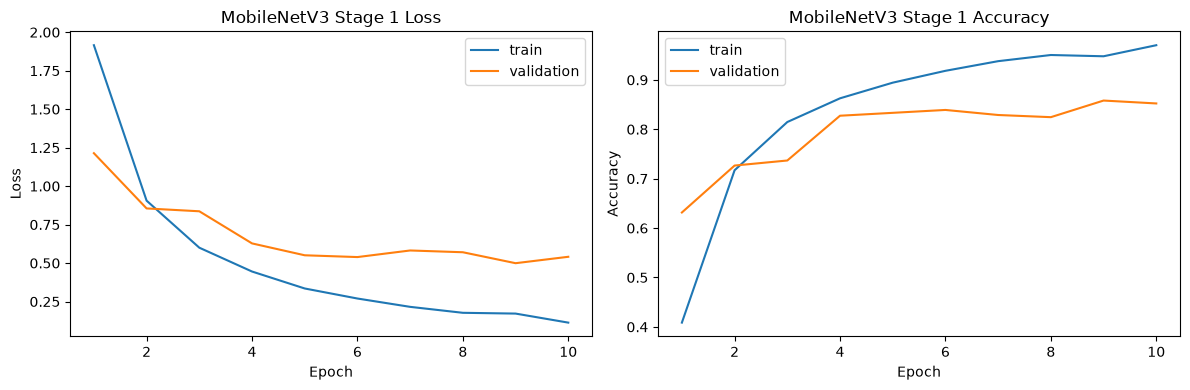

In [23]:
mobilenet_history_df = pd.DataFrame(
    mobilenet_history_stage1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Loss
axes[0].plot(
    mobilenet_history_df["epoch"],
    mobilenet_history_df["train_loss"],
    label="train"
)

axes[0].plot(
    mobilenet_history_df["epoch"],
    mobilenet_history_df["val_loss"],
    label="validation"
)

axes[0].set_title(
    "MobileNetV3 Stage 1 Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Accuracy
axes[1].plot(
    mobilenet_history_df["epoch"],
    mobilenet_history_df["train_acc"],
    label="train"
)

axes[1].plot(
    mobilenet_history_df["epoch"],
    mobilenet_history_df["val_acc"],
    label="validation"
)

axes[1].set_title(
    "MobileNetV3 Stage 1 Accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Validation Error Analysis

The best MobileNetV3 Stage 1 checkpoint is analyzed on the validation set before further fine-tuning.

The goal is to identify:
- which Balinese characters are recognized reliably
- which classes have lower precision or recall
- which visually similar characters are frequently confused

This analysis helps determine whether the next improvement should focus on model fine-tuning, preprocessing, or data augmentation.

The test set remains untouched.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best Stage 1 checkpoint
mobilenet_model.load_state_dict(
    torch.load(
        "../outputs/mobilenetv3_stage1_best.pt",
        map_location=device
    )
)

mobilenet_model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in mobilenet_val_loader:
        images = images.to(device)

        outputs = mobilenet_model(images)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          ba     0.8000    0.8421    0.8205        38
          ca     0.8485    0.7368    0.7887        38
          da     0.8333    0.9211    0.8750        38
          ga     0.7941    0.7105    0.7500        38
          ha     0.8947    0.8947    0.8947        38
          ja     0.8462    0.8684    0.8571        38
          ka     0.8444    1.0000    0.9157        38
          la     0.9394    0.8158    0.8732        38
          ma     0.8462    0.8684    0.8571        38
          na     0.9118    0.8158    0.8611        38
         nga     0.9310    0.7105    0.8060        38
         nya     0.8919    0.8684    0.8800        38
          pa     0.9655    0.7368    0.8358        38
          ra     0.8750    0.9211    0.8974        38
          sa     0.7907    0.8947    0.8395        38
          ta     0.7551    0.9737    0.8506        38
          wa     0.8684    0.8684    0.8684        38
          ya     0.9048    

### Validation Confusion Matrix

A confusion matrix is used to inspect which Balinese characters are frequently misclassified as one another.

This is particularly important for handwriting recognition because several characters may share similar visual structures.

The analysis is performed only on the validation set so that the test set remains untouched during model development.

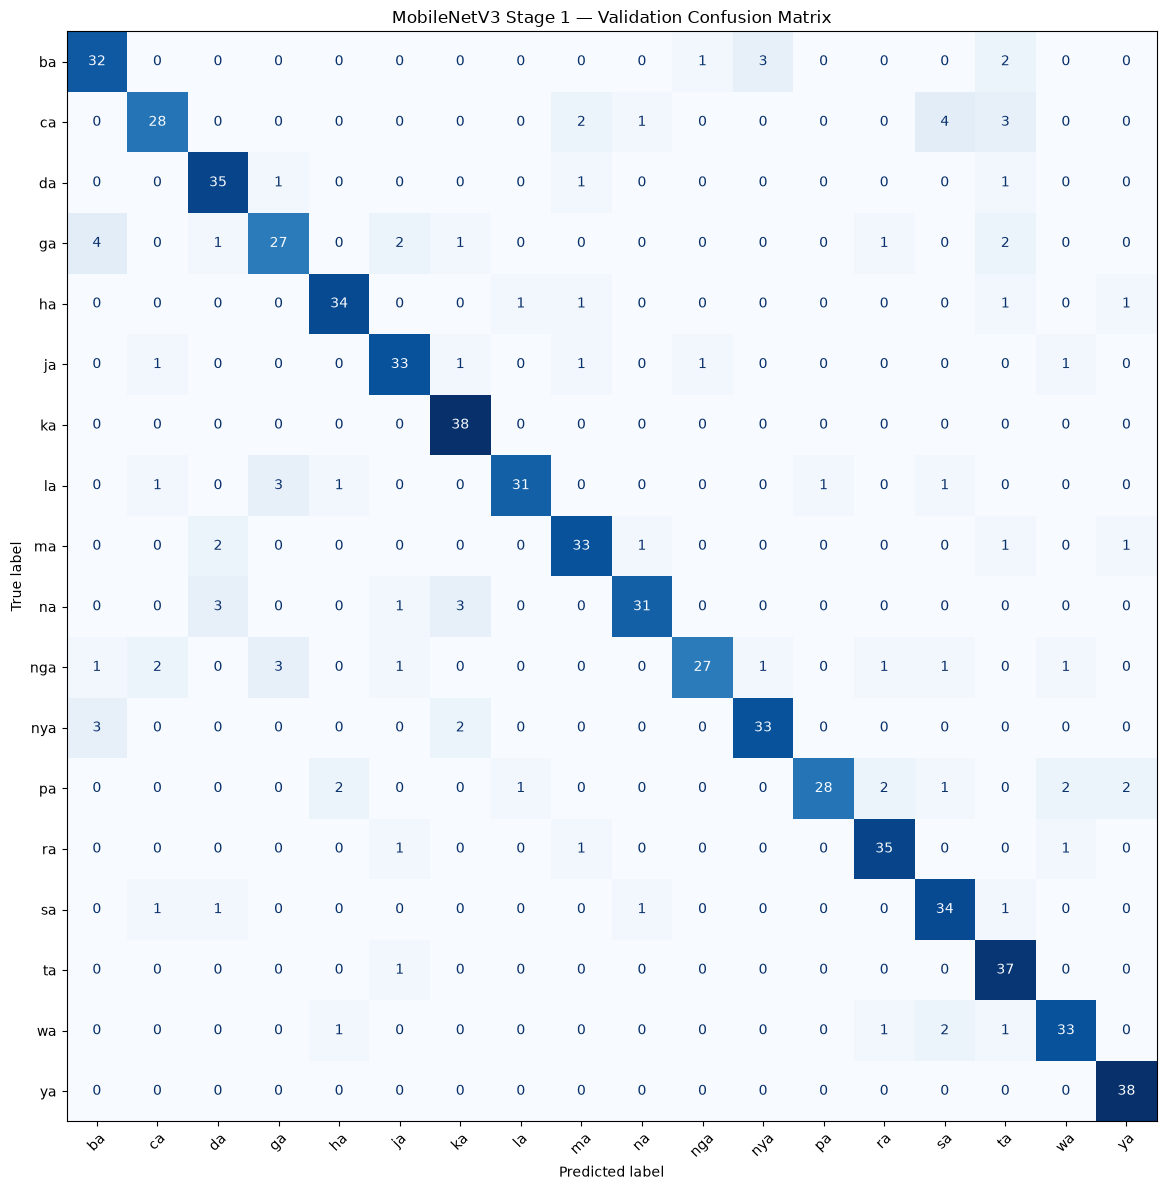

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

fig, ax = plt.subplots(
    figsize=(12, 12)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title(
    "MobileNetV3 Stage 1 — Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

## 10. Stage 2 — Partial Fine-Tuning

Validation error analysis showed that most remaining errors occur between visually similar Balinese characters rather than random classes.

Examples include confusion between:
- ga and ba
- ca and sa
- na and da
- na and ka
- nga and ga
- nya and ba

The pretrained MobileNetV3 features already provide strong performance, but they may not yet capture the subtle visual structures required to distinguish similar Balinese handwriting.

For Stage 2, the best Stage 1 checkpoint is used and only the final feature blocks of MobileNetV3 are unfrozen.

A lower learning rate is used to adapt the pretrained visual features without aggressively modifying them.

The test set remains untouched.

In [26]:
# Reload the best Stage 1 checkpoint
mobilenet_model.load_state_dict(
    torch.load(
        "../outputs/mobilenetv3_stage1_best.pt",
        map_location=device
    )
)

# Freeze everything first
for param in mobilenet_model.parameters():
    param.requires_grad = False

# Unfreeze the last 3 feature blocks
for block in mobilenet_model.features[-3:]:
    for param in block.parameters():
        param.requires_grad = True

# Keep classifier trainable
for param in mobilenet_model.classifier.parameters():
    param.requires_grad = True

trainable_params_stage2 = sum(
    p.numel()
    for p in mobilenet_model.parameters()
    if p.requires_grad
)

print(
    "stage 2 trainable parameters:",
    trainable_params_stage2
)

stage 2 trainable parameters: 3003378


### Stage 2 Fine-Tuning Configuration

The last three MobileNetV3 feature blocks are fine-tuned together with the classifier.

Different learning rates are used for each part of the model:

- pretrained feature blocks use a very small learning rate to preserve useful pretrained representations
- the classifier uses a slightly larger learning rate because it is specific to the 18 Balinese character classes

This stage starts from the best Stage 1 checkpoint rather than training from scratch.

In [27]:
import torch.optim as optim

backbone_params = [
    p
    for block in mobilenet_model.features[-3:]
    for p in block.parameters()
    if p.requires_grad
]

classifier_params = [
    p
    for p in mobilenet_model.classifier.parameters()
    if p.requires_grad
]

optimizer_stage2 = optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": 1e-5
        },
        {
            "params": classifier_params,
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)

EPOCHS_STAGE2 = 8

print("backbone lr:", optimizer_stage2.param_groups[0]["lr"])
print("classifier lr:", optimizer_stage2.param_groups[1]["lr"])
print("epochs:", EPOCHS_STAGE2)

backbone lr: 1e-05
classifier lr: 0.0001
epochs: 8


### Stage 2 Partial Fine-Tuning Loop

During Stage 2, MobileNetV3 is partially fine-tuned.

The earlier pretrained feature blocks remain frozen and stay in evaluation mode, while the final three feature blocks and classifier are trained.

This preserves the more general pretrained visual representations while allowing the deeper features to adapt to the visual characteristics of Balinese handwriting.

In [28]:
def train_one_epoch_partial_finetune(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Keep earlier frozen feature blocks in evaluation mode
    model.features[:-3].eval()

    # Fine-tune the final three feature blocks
    model.features[-3:].train()

    # Train classifier
    model.classifier.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### MobileNetV3 Stage 2 Training

The best Stage 1 MobileNetV3 checkpoint is further improved through partial fine-tuning.

During this stage:
- the last three MobileNetV3 feature blocks are unfrozen
- earlier feature blocks remain frozen
- the classifier continues to train
- a smaller learning rate is used for the pretrained feature blocks
- the best model is selected using validation accuracy

The test set remains untouched.

In [29]:
mobilenet_history_stage2 = []
best_val_acc_stage2 = 0.0

for epoch in range(EPOCHS_STAGE2):

    train_loss, train_acc = train_one_epoch_partial_finetune(
        mobilenet_model,
        mobilenet_train_loader,
        criterion,
        optimizer_stage2,
        device
    )

    val_loss, val_acc = evaluate(
        mobilenet_model,
        mobilenet_val_loader,
        criterion,
        device
    )

    mobilenet_history_stage2.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    if val_acc > best_val_acc_stage2:
        best_val_acc_stage2 = val_acc

        torch.save(
            mobilenet_model.state_dict(),
            "../outputs/mobilenetv3_stage2_best.pt"
        )

    print(
        f"epoch {epoch + 1:02d}/{EPOCHS_STAGE2} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.4f}"
    )

print(
    f"\nbest validation accuracy: "
    f"{best_val_acc_stage2:.4f}"
)

print(
    f"stage 1 best validation accuracy: "
    f"{best_val_acc_stage1:.4f}"
)

epoch 01/8 | train loss: 1.2710 | train acc: 0.6170 | val loss: 0.7060 | val acc: 0.7982
epoch 02/8 | train loss: 0.6793 | train acc: 0.7792 | val loss: 0.6596 | val acc: 0.8099
epoch 03/8 | train loss: 0.4800 | train acc: 0.8426 | val loss: 0.6215 | val acc: 0.8158
epoch 04/8 | train loss: 0.3396 | train acc: 0.8963 | val loss: 0.5893 | val acc: 0.8114
epoch 05/8 | train loss: 0.2739 | train acc: 0.9174 | val loss: 0.5504 | val acc: 0.8187
epoch 06/8 | train loss: 0.2113 | train acc: 0.9354 | val loss: 0.5252 | val acc: 0.8480
epoch 07/8 | train loss: 0.1665 | train acc: 0.9539 | val loss: 0.5017 | val acc: 0.8406
epoch 08/8 | train loss: 0.1209 | train acc: 0.9690 | val loss: 0.4797 | val acc: 0.8582

best validation accuracy: 0.8582
stage 1 best validation accuracy: 0.8582


## 11. Stage 1 vs Stage 2 Validation Comparison

Partial fine-tuning did not improve the best validation accuracy beyond the frozen-backbone Stage 1 model.

Both stages achieved a best validation accuracy of 85.82%.

However, Stage 2 produced a slightly lower validation loss, so additional class-level evaluation is performed before deciding which checkpoint should be retained.

The comparison focuses on:
- accuracy
- macro precision
- macro recall
- macro F1-score
- per-class performance

The test set remains untouched.

In [30]:
from sklearn.metrics import classification_report
import numpy as np

# Load best Stage 2 checkpoint
mobilenet_model.load_state_dict(
    torch.load(
        "../outputs/mobilenetv3_stage2_best.pt",
        map_location=device
    )
)

mobilenet_model.eval()

stage2_labels = []
stage2_predictions = []

with torch.no_grad():
    for images, labels in mobilenet_val_loader:
        images = images.to(device)

        outputs = mobilenet_model(images)
        predictions = outputs.argmax(dim=1)

        stage2_labels.extend(labels.numpy())
        stage2_predictions.extend(
            predictions.cpu().numpy()
        )

stage2_labels = np.array(stage2_labels)
stage2_predictions = np.array(stage2_predictions)

print(
    classification_report(
        stage2_labels,
        stage2_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          ba     0.7750    0.8158    0.7949        38
          ca     0.8684    0.8684    0.8684        38
          da     0.8500    0.8947    0.8718        38
          ga     0.8571    0.7895    0.8219        38
          ha     0.8500    0.8947    0.8718        38
          ja     0.8485    0.7368    0.7887        38
          ka     0.9487    0.9737    0.9610        38
          la     0.8000    0.8421    0.8205        38
          ma     0.8000    0.8421    0.8205        38
          na     0.9231    0.9474    0.9351        38
         nga     0.8387    0.6842    0.7536        38
         nya     0.8649    0.8421    0.8533        38
          pa     0.9697    0.8421    0.9014        38
          ra     0.8537    0.9211    0.8861        38
          sa     0.8250    0.8684    0.8462        38
          ta     0.8611    0.8158    0.8378        38
          wa     0.8462    0.8684    0.8571        38
          ya     0.8837    

### Stage 1 vs Stage 2 Conclusion

Partial fine-tuning did not produce a meaningful overall improvement.

Both Stage 1 and Stage 2 achieved 85.82% validation accuracy, while their macro F1-scores were nearly identical at 85.67% and 85.71%.

Fine-tuning improved several classes such as `ca`, `ga`, and `na`, but reduced performance on others such as `ja`, `nga`, and `la`.

Therefore, the frozen-backbone Stage 1 model is retained as the current best candidate because additional backbone fine-tuning did not provide a clear performance benefit.

## 12. Handwriting Variation Augmentation

The previous fine-tuning experiment did not meaningfully improve overall validation performance.

The next iteration focuses on the training data rather than increasing model complexity.

Since the target application must recognize natural handwriting variations, mild geometric augmentation is introduced only to the training set.

The augmentation simulates realistic differences in:
- position
- scale
- slight rotation

Horizontal and vertical flipping are avoided because they could change the structural meaning of a Balinese character.

Validation and test images remain unchanged.

In [31]:
mobilenet_train_transform_aug = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),

    transforms.RandomAffine(
        degrees=8,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10),
        fill=255
    ),

    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print(mobilenet_train_transform_aug)

Compose(
    Lambda()
    RandomAffine(degrees=[-8.0, 8.0], translate=(0.08, 0.08), scale=(0.9, 1.1), fill=255)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Augmentation Visual Check

Before using augmentation for training, random transformed samples are visually inspected.

The objective is to verify that variations in rotation, translation, and scale remain realistic while preserving the character structure.

If the augmented characters remain recognizable and are not excessively cropped or distorted, the augmentation can be used for the next training experiment.

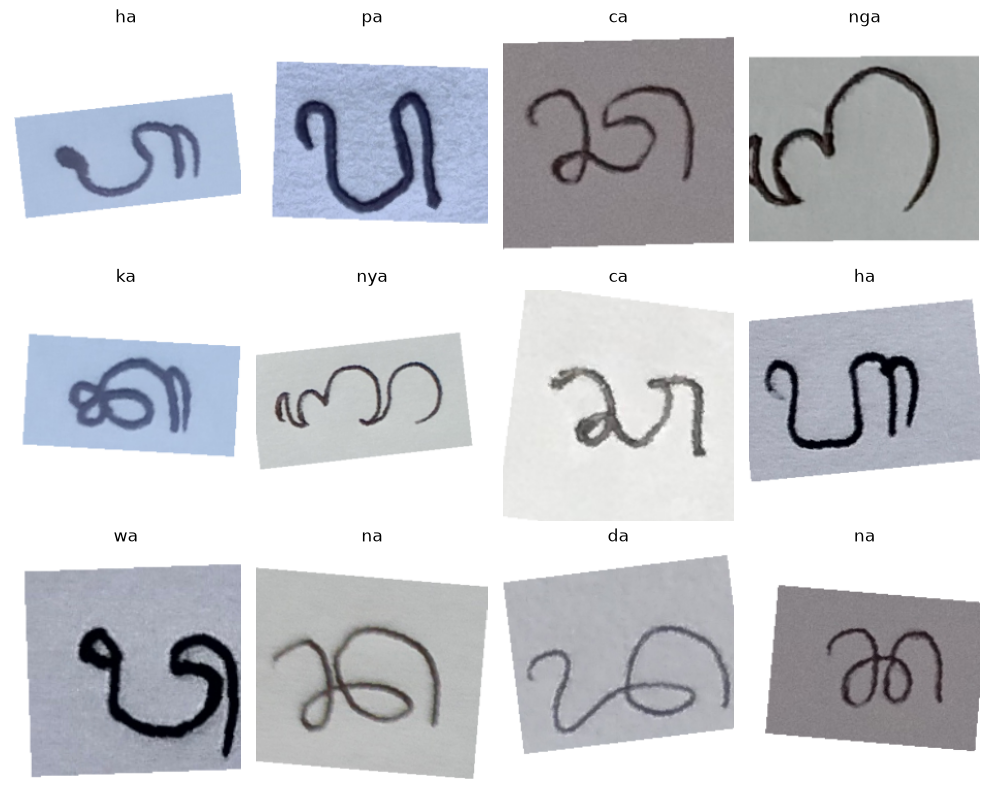

In [32]:
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_rows = train_df.sample(
    n=12,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

for ax, (_, row) in zip(
    axes.flat,
    sample_rows.iterrows()
):
    image = Image.open(row["path"])

    augmented = mobilenet_train_transform_aug(image)

    # Undo ImageNet normalization for visualization
    augmented = augmented.permute(1, 2, 0)

    mean = torch.tensor(imagenet_mean)
    std = torch.tensor(imagenet_std)

    augmented = augmented * std + mean
    augmented = augmented.clamp(0, 1)

    ax.imshow(augmented)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Augmented Training Dataset

A new training dataset is created using the handwriting augmentation pipeline.

Only the training subset receives random geometric augmentation.

The validation dataset remains unchanged so that the augmented model can be compared fairly with the previous MobileNetV3 experiments.

In [33]:
mobilenet_train_dataset_aug = BalineseHandwritingDataset(
    train_df,
    transform=mobilenet_train_transform_aug
)

mobilenet_train_loader_aug = DataLoader(
    mobilenet_train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("augmented train samples:", len(mobilenet_train_dataset_aug))
print("validation samples:", len(mobilenet_val_dataset))

augmented train samples: 3125
validation samples: 684


### Augmentation Experiment — Fresh MobileNetV3

A fresh MobileNetV3-Large model is initialized using the same ImageNet pretrained weights as Stage 1.

The feature extractor is frozen and only the classifier is trained.

This keeps the model configuration consistent with Stage 1, so the effect of handwriting augmentation can be evaluated fairly.

In [34]:
torch.manual_seed(42)

weights = models.MobileNet_V3_Large_Weights.DEFAULT

mobilenet_model_aug = models.mobilenet_v3_large(
    weights=weights
)

# Freeze pretrained feature extractor
for param in mobilenet_model_aug.features.parameters():
    param.requires_grad = False

# Replace classifier output for 18 classes
in_features = mobilenet_model_aug.classifier[3].in_features

mobilenet_model_aug.classifier[3] = nn.Linear(
    in_features,
    len(class_names)
)

mobilenet_model_aug = mobilenet_model_aug.to(device)

total_params_aug = sum(
    p.numel()
    for p in mobilenet_model_aug.parameters()
)

trainable_params_aug = sum(
    p.numel()
    for p in mobilenet_model_aug.parameters()
    if p.requires_grad
)

print("total parameters:", total_params_aug)
print("trainable parameters:", trainable_params_aug)
print("device:", next(mobilenet_model_aug.parameters()).device)

total parameters: 4225090
trainable parameters: 1253138
device: mps:0


### Augmentation Experiment Configuration

The augmented MobileNetV3 experiment uses the same training configuration as Stage 1.

Keeping the optimizer, learning rate, number of epochs, and frozen backbone unchanged allows the effect of handwriting augmentation to be compared fairly against the original Stage 1 model.

In [35]:
criterion_aug = nn.CrossEntropyLoss()

optimizer_aug = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        mobilenet_model_aug.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_AUG = 10

print("learning rate:", optimizer_aug.param_groups[0]["lr"])
print("epochs:", EPOCHS_AUG)
print(
    "trainable parameters:",
    sum(
        p.numel()
        for p in mobilenet_model_aug.parameters()
        if p.requires_grad
    )
)

learning rate: 0.001
epochs: 10
trainable parameters: 1253138


### Augmented MobileNetV3 Training

The MobileNetV3 model is trained using the augmented handwriting dataset while keeping the pretrained feature extractor frozen.

The training configuration is kept identical to Stage 1 so that validation performance can be compared directly.

The checkpoint with the highest validation accuracy is saved for further evaluation.

In [36]:
mobilenet_history_aug = []
best_val_acc_aug = 0.0

for epoch in range(EPOCHS_AUG):

    train_loss, train_acc = train_one_epoch_frozen_backbone(
        mobilenet_model_aug,
        mobilenet_train_loader_aug,
        criterion_aug,
        optimizer_aug,
        device
    )

    val_loss, val_acc = evaluate(
        mobilenet_model_aug,
        mobilenet_val_loader,
        criterion_aug,
        device
    )

    mobilenet_history_aug.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc

        torch.save(
            mobilenet_model_aug.state_dict(),
            "../outputs/mobilenetv3_aug_best.pt"
        )

    print(
        f"epoch {epoch + 1:02d}/{EPOCHS_AUG} | "
        f"train loss: {train_loss:.4f} | "
        f"train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val acc: {val_acc:.4f}"
    )

print(
    f"\nbest augmented validation accuracy: "
    f"{best_val_acc_aug:.4f}"
)

print(
    f"stage 1 best validation accuracy: "
    f"{best_val_acc_stage1:.4f}"
)

epoch 01/10 | train loss: 2.0005 | train acc: 0.3738 | val loss: 1.3788 | val acc: 0.5570
epoch 02/10 | train loss: 1.0971 | train acc: 0.6429 | val loss: 1.0197 | val acc: 0.6740
epoch 03/10 | train loss: 0.8301 | train acc: 0.7283 | val loss: 0.9473 | val acc: 0.6901
epoch 04/10 | train loss: 0.6570 | train acc: 0.7830 | val loss: 0.7531 | val acc: 0.7734
epoch 05/10 | train loss: 0.5573 | train acc: 0.8243 | val loss: 0.7167 | val acc: 0.7734
epoch 06/10 | train loss: 0.5052 | train acc: 0.8314 | val loss: 0.6956 | val acc: 0.8099
epoch 07/10 | train loss: 0.4882 | train acc: 0.8349 | val loss: 0.6296 | val acc: 0.7982
epoch 08/10 | train loss: 0.4165 | train acc: 0.8614 | val loss: 0.6505 | val acc: 0.8041
epoch 09/10 | train loss: 0.3557 | train acc: 0.8832 | val loss: 0.6510 | val acc: 0.8041
epoch 10/10 | train loss: 0.3196 | train acc: 0.8957 | val loss: 0.6699 | val acc: 0.8012

best augmented validation accuracy: 0.8099
stage 1 best validation accuracy: 0.8582


### Augmentation Experiment Evaluation

The augmentation experiment reached a best validation accuracy of 80.99%, which is lower than the 85.82% achieved by the original Stage 1 model.

This indicates that the current augmentation configuration did not improve overall validation performance.

Before rejecting the augmentation strategy, class-level performance is evaluated to determine whether certain characters benefited from the additional handwriting variation.

In [37]:
# Load best augmented checkpoint
mobilenet_model_aug.load_state_dict(
    torch.load(
        "../outputs/mobilenetv3_aug_best.pt",
        map_location=device
    )
)

mobilenet_model_aug.eval()

aug_labels = []
aug_predictions = []

with torch.no_grad():
    for images, labels in mobilenet_val_loader:
        images = images.to(device)

        outputs = mobilenet_model_aug(images)
        predictions = outputs.argmax(dim=1)

        aug_labels.extend(labels.numpy())
        aug_predictions.extend(
            predictions.cpu().numpy()
        )

aug_labels = np.array(aug_labels)
aug_predictions = np.array(aug_predictions)

print(
    classification_report(
        aug_labels,
        aug_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          ba     0.8462    0.5789    0.6875        38
          ca     0.7381    0.8158    0.7750        38
          da     0.7174    0.8684    0.7857        38
          ga     0.7838    0.7632    0.7733        38
          ha     0.8095    0.8947    0.8500        38
          ja     0.7317    0.7895    0.7595        38
          ka     0.9250    0.9737    0.9487        38
          la     0.7742    0.6316    0.6957        38
          ma     0.7692    0.7895    0.7792        38
          na     1.0000    0.7632    0.8657        38
         nga     0.8800    0.5789    0.6984        38
         nya     0.8537    0.9211    0.8861        38
          pa     0.9167    0.8684    0.8919        38
          ra     1.0000    0.8158    0.8986        38
          sa     0.9677    0.7895    0.8696        38
          ta     0.5323    0.8684    0.6600        38
          wa     0.8462    0.8684    0.8571        38
          ya     0.8261    

### Mild Handwriting Augmentation

The first augmentation experiment reduced validation accuracy from 85.82% to 80.99%.

Although several classes improved, the overall degradation suggests that the transformations were too strong for the current dataset.

A milder augmentation configuration is therefore tested using smaller changes in rotation, translation, and scale.

This experiment aims to introduce realistic handwriting variation without excessively changing the original character structure.

In [38]:
mobilenet_train_transform_mild_aug = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    PadToSquare(),

    transforms.RandomAffine(
        degrees=4,
        translate=(0.04, 0.04),
        scale=(0.95, 1.05),
        fill=255
    ),

    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print(mobilenet_train_transform_mild_aug)

Compose(
    Lambda()
    RandomAffine(degrees=[-4.0, 4.0], translate=(0.04, 0.04), scale=(0.95, 1.05), fill=255)
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### Mild Augmentation Visual Check

The milder augmentation configuration is visually inspected before training.

The goal is to confirm that small changes in rotation, position, and scale still resemble realistic handwriting variation without noticeably altering the character structure.

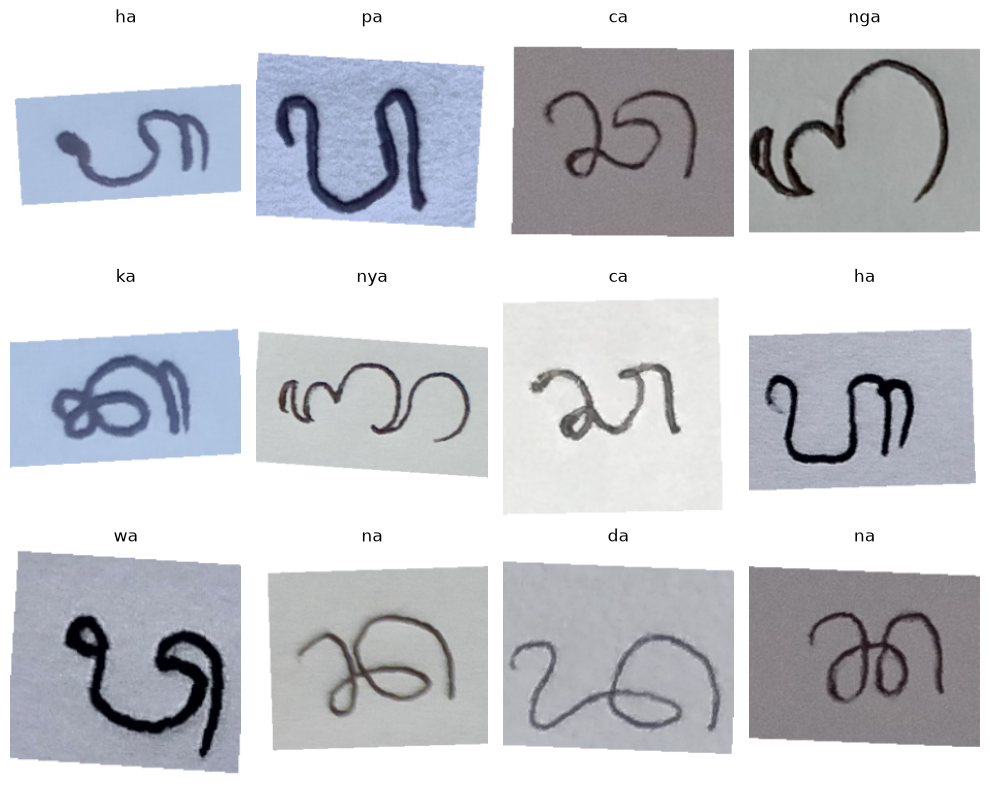

In [39]:
sample_rows_mild = train_df.sample(
    n=12,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

for ax, (_, row) in zip(
    axes.flat,
    sample_rows_mild.iterrows()
):
    image = Image.open(row["path"])

    augmented = mobilenet_train_transform_mild_aug(image)

    # Undo normalization for visualization
    augmented = augmented.permute(1, 2, 0)

    mean = torch.tensor(imagenet_mean)
    std = torch.tensor(imagenet_std)

    augmented = augmented * std + mean
    augmented = augmented.clamp(0, 1)

    ax.imshow(augmented)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Mild Augmentation Training Dataset

A new training dataset is created using the milder augmentation pipeline.

Only the training set receives augmentation, while the validation set remains unchanged for a fair comparison with the original Stage 1 model.

In [40]:
mobilenet_train_dataset_mild_aug = BalineseHandwritingDataset(
    train_df,
    transform=mobilenet_train_transform_mild_aug
)

mobilenet_train_loader_mild_aug = DataLoader(
    mobilenet_train_dataset_mild_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(
    "mild augmented train samples:",
    len(mobilenet_train_dataset_mild_aug)
)

print(
    "validation samples:",
    len(mobilenet_val_dataset)
)

mild augmented train samples: 3125
validation samples: 684
